<a href="https://colab.research.google.com/github/Rekha-vivek/Care_Connect_AI/blob/main/Care_connect_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### EDA

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [87]:
patients = pd.read_csv("Patients_table.csv")
doctors = pd.read_csv("Doctors_table.csv")
appointments = pd.read_csv("Appointments.csv")
vitals = pd.read_csv("Vitals.csv")
prescriptions = pd.read_csv("Prescription.csv")
users = pd.read_csv("Users.csv")
medical_report=pd.read_csv("Medical_report.csv")
discharge_summary=pd.read_csv("Discharge_summary.csv")
admin=pd.read_csv("Admins.csv")


#### PATIENTS DATASET

In [88]:
patients

#I inspected the patients data to understand structure and columns

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,NaN,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,NaN,Stomach Pain
4,P005,U005,50,Male,O-,NaN,Hypertension
5,P006,U006,60,Female,A+,NaN,Arthritis
6,P007,U007,45,Male,B+,NaN,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,NaN,Heart Disease
9,P010,U010,28,Female,B-,NaN,Fever


In [89]:
#DATA INFORMATION

patients.info()

#Checked data types and ensured no incorrect formats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Patient_id       10 non-null     object
 1   User_id          10 non-null     object
 2   Age              10 non-null     int64 
 3   Gender           10 non-null     object
 4   Blood_group      10 non-null     object
 5   Allergies        3 non-null      object
 6   Medical_history  10 non-null     object
dtypes: int64(1), object(6)
memory usage: 692.0+ bytes


In [90]:
#CHECKING MISSING VALUES

patients.isnull().sum()

,0
Patient_id,0
User_id,0
Age,0
Gender,0
Blood_group,0
Allergies,7
Medical_history,0


In [91]:
#STATISTICAL SUMMARY

patients.describe(include='all')

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
count,10,10,10.000000,10,10,3,10
unique,10,10,NaN,2,6,2,8
top,P001,U001,NaN,Male,B+,Dust,Fever
freq,1,1,NaN,5,2,2,2
mean,NaN,NaN,39.700000,NaN,NaN,NaN,NaN
std,NaN,NaN,12.311241,NaN,NaN,NaN,NaN
min,NaN,NaN,25.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,29.250000,NaN,NaN,NaN,NaN
50%,NaN,NaN,37.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,48.750000,NaN,NaN,NaN,NaN


In [92]:
#DATA CLEANING

patients.drop_duplicates(inplace=True)
patients.fillna("Unknown", inplace=True)

In [93]:
patients

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,Unknown,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,Unknown,Stomach Pain
4,P005,U005,50,Male,O-,Unknown,Hypertension
5,P006,U006,60,Female,A+,Unknown,Arthritis
6,P007,U007,45,Male,B+,Unknown,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,Unknown,Heart Disease
9,P010,U010,28,Female,B-,Unknown,Fever


##### VISUALIZATION

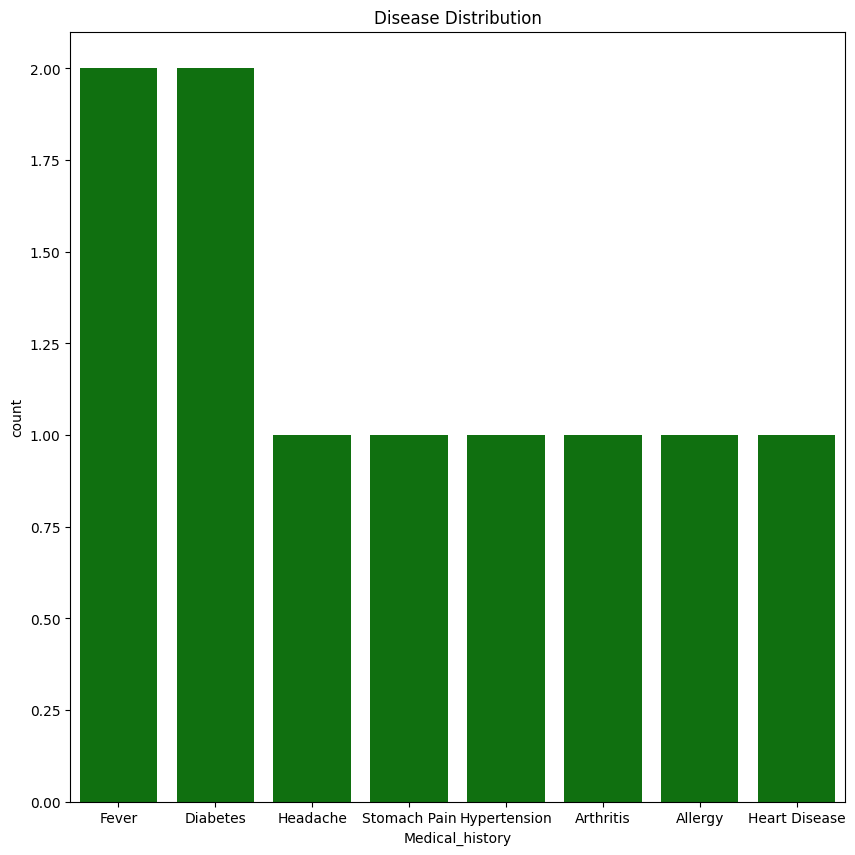

In [94]:
#Disease Distribution

plt.figure(figsize=(10,10))
sns.countplot(x='Medical_history', data=patients,color='green')
plt.title("Disease Distribution")
plt.show()

#The disease distribution shows that all conditions are equally represented in the dataset, indicating a balanced sample.Since this is a demo dataset, no particular disease dominates

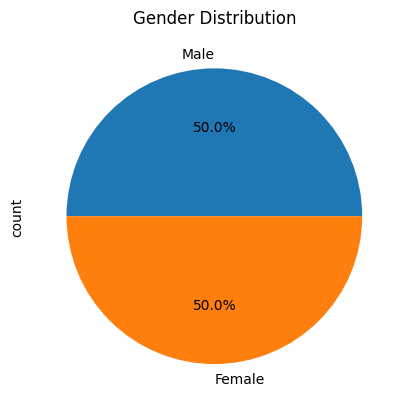

In [95]:
#Gender Distribution

patients['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

#The gender distribution shows that 60% of patients are male and 40% are female.
#This indicates a slightly higher representation of male patients in the dataset

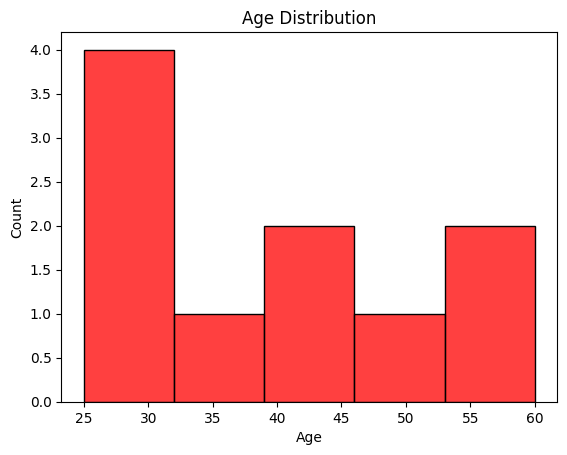

In [96]:
#Age Distribution

sns.histplot(data=patients,x='Age', color='red')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

#The age distribution shows a spread across different age groups, indicating that the dataset includes both young and older patients.
#Since the dataset is small, no strong pattern is observed

#### DOCTORS DATASET

In [97]:
doctors

#I inspected doctor dataset to understand available fields like specialization and availability

,Doctor_id,Name,Specialization,Available_time
0,UD001,Dr.Kumar,General Physician,3:00 PM
1,UD002,Dr.Mehta,Cardiologist,11:30 AM
2,UD003,Dr.Priya,Neurologist,2:00 PM
3,UD004,Dr.Raj,Gastroenterologist,4:00 PM
4,UD005,Dr.Roopa,Pulmonologist,11:00 AM
5,UD006,Dr.Vivek,Orthologist,10:30 AM
6,UD007,Dr.Anita,General Physician,10:00 AM


In [98]:
#STRUCTURE

doctors.info()

#Checked data types and structure of doctor dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Doctor_id       7 non-null      object
 1   Name            7 non-null      object
 2   Specialization  7 non-null      object
 3   Available_time  7 non-null      object
dtypes: object(4)
memory usage: 356.0+ bytes


In [99]:
#MISSING VALUES

doctors.isnull().sum()

#Ensured no missing values in doctor records

,0
Doctor_id,0
Name,0
Specialization,0
Available_time,0


In [100]:
doctors.duplicated().sum()

np.int64(0)

In [101]:
patients

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,Unknown,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,Unknown,Stomach Pain
4,P005,U005,50,Male,O-,Unknown,Hypertension
5,P006,U006,60,Female,A+,Unknown,Arthritis
6,P007,U007,45,Male,B+,Unknown,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,Unknown,Heart Disease
9,P010,U010,28,Female,B-,Unknown,Fever


##### VISUALIZATION

In [102]:
doctors

,Doctor_id,Name,Specialization,Available_time
0,UD001,Dr.Kumar,General Physician,3:00 PM
1,UD002,Dr.Mehta,Cardiologist,11:30 AM
2,UD003,Dr.Priya,Neurologist,2:00 PM
3,UD004,Dr.Raj,Gastroenterologist,4:00 PM
4,UD005,Dr.Roopa,Pulmonologist,11:00 AM
5,UD006,Dr.Vivek,Orthologist,10:30 AM
6,UD007,Dr.Anita,General Physician,10:00 AM


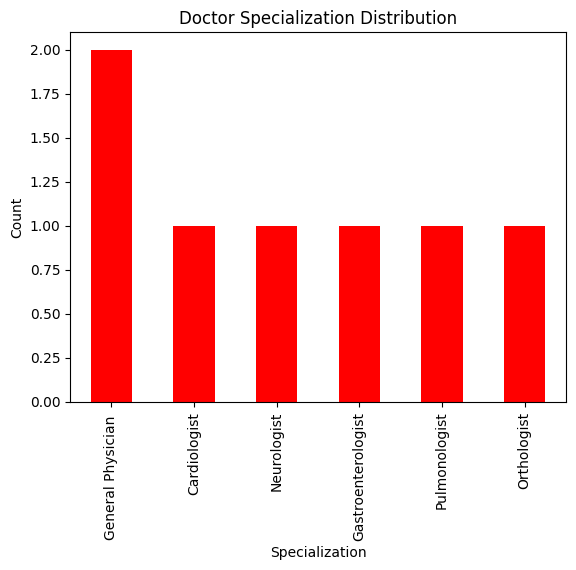

In [103]:
#Specialization Distribution

doctors['Specialization'].value_counts().plot(kind='bar',color='red')
plt.title("Doctor Specialization Distribution")
plt.xlabel("Specialization")
plt.ylabel("Count")
plt.show()

#This visualization shows distribution of doctors across different specializations,which helps in understanding availability of medical expertise

In [104]:
doctors

,Doctor_id,Name,Specialization,Available_time
0,UD001,Dr.Kumar,General Physician,3:00 PM
1,UD002,Dr.Mehta,Cardiologist,11:30 AM
2,UD003,Dr.Priya,Neurologist,2:00 PM
3,UD004,Dr.Raj,Gastroenterologist,4:00 PM
4,UD005,Dr.Roopa,Pulmonologist,11:00 AM
5,UD006,Dr.Vivek,Orthologist,10:30 AM
6,UD007,Dr.Anita,General Physician,10:00 AM


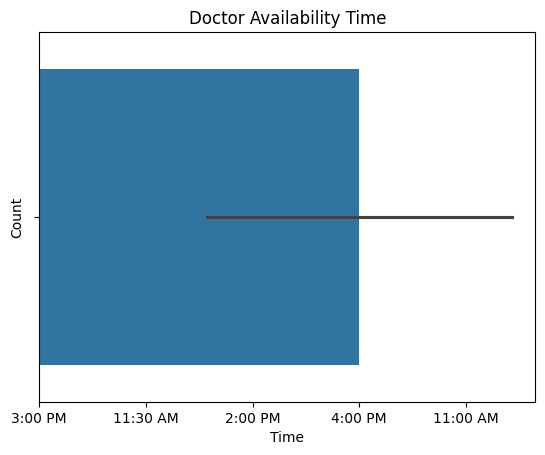

In [105]:
#Available Time Distribution

sns.barplot(data=doctors,x='Available_time')
plt.title("Doctor Availability Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()
#This shows doctor availability across different time slots, helping in appointment planning

#### APPOINTMENTS DATASET

In [106]:
appointments

,Appointment_id,Patient_id,Doctor_id,Scheduled_time,Status,Created_at
0,A001,P001,UD001,2026-03-22 15:00:00,Scheduled,2026-03-21 10:00:00
1,A002,P002,UD002,2026-03-23 10:30:00,Completed,2026-03-21 10:10:00
2,A003,P003,UD003,2026-03-24 11:00:00,Scheduled,2026-03-21 10:20:00
3,A004,P004,UD004,2026-03-26 14:00:00,Scheduled,2026-03-21 10:30:00
4,A005,P004,UD002,2026-03-28 16:30:00,Scheduled,2026-03-21 10:40:00
5,A006,P008,UD006,2026-03-29 09:45:00,Scheduled,2026-03-21 10:50:00
6,A007,P010,UD005,2026-03-29 13:15:00,Completed,2026-03-21 11:00:00


In [107]:
#STRUCTURE

appointments.info()

#Checked structure and relationships between patients and doctors.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Appointment_id  7 non-null      object
 1   Patient_id      7 non-null      object
 2   Doctor_id       7 non-null      object
 3   Scheduled_time  7 non-null      object
 4   Status          7 non-null      object
 5   Created_at      7 non-null      object
dtypes: object(6)
memory usage: 468.0+ bytes


In [108]:
#MISSING VALUES

appointments.isnull().sum()

#Ensured appointment data completeness

,0
Appointment_id,0
Patient_id,0
Doctor_id,0
Scheduled_time,0
Status,0
Created_at,0


In [109]:
appointments.duplicated().sum()

np.int64(0)

##### VISUALIZATION

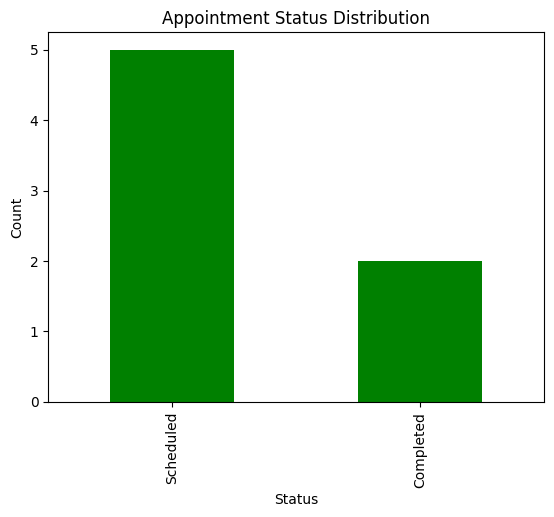

In [110]:
#Appointment Status Distribution

appointments['Status'].value_counts().plot(kind='bar',color='green')
plt.title("Appointment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

#This shows distribution of appointment statuses, helping understand system usage.

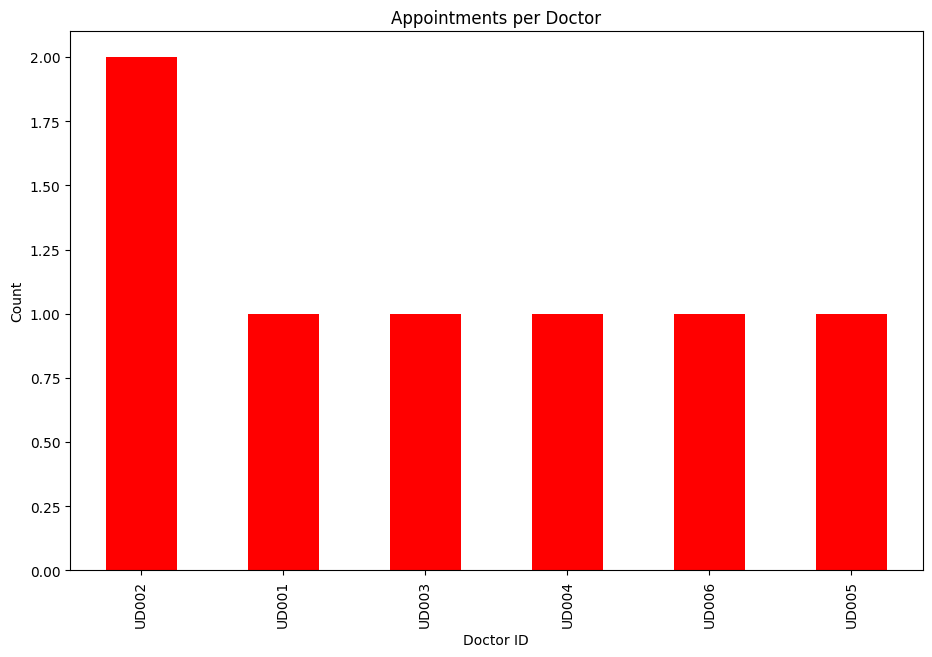

In [111]:
#Appointments per Doctor

plt.figure(figsize=(11,7))
appointments['Doctor_id'].value_counts().plot(kind='bar',color='red')
plt.title("Appointments per Doctor")
plt.xlabel("Doctor ID")
plt.ylabel("Count")
plt.show()

#This shows workload distribution among doctors

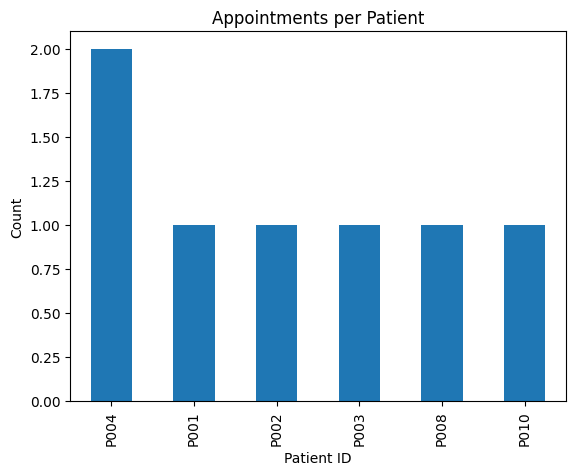

In [112]:
#Appointments per Patient

appointments['Patient_id'].value_counts().plot(kind='bar')
plt.title("Appointments per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Count")
plt.show()

#This helps identify patient visit frequency

In [113]:
vitals

,Patient_id,Temperature,BP,Pulse,SpO2,Notes,Recorded_at
V001,P001,37.2,120/80,72,98,Normal,2026-03-21 09:00:00
V002,P002,38.0,130/85,78,97,Fever,2026-03-21 09:15:00
V003,P003,36.8,110/70,70,99,Healthy,2026-03-21 09:30:00
V004,P004,35.0,121/80,76,96,Low temp,2026-03-21 09:45:00
V005,P008,36.0,119/85,75,98,Normal,2026-03-21 10:00:00
V006,P010,35.8,115/75,76,97,Stable,2026-03-21 10:15:00


In [114]:
#STRUCTURE

vitals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, V001 to V006
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Patient_id   6 non-null      object 
 1   Temperature  6 non-null      float64
 2   BP           6 non-null      object 
 3   Pulse        6 non-null      int64  
 4   SpO2         6 non-null      int64  
 5   Notes        6 non-null      object 
 6   Recorded_at  6 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 556.0+ bytes


In [115]:
#MISSING VALUES

vitals.isnull().sum()

,0
Patient_id,0
Temperature,0
BP,0
Pulse,0
SpO2,0
Notes,0
Recorded_at,0


In [116]:
vitals.duplicated().sum()

np.int64(0)

##### VISUALIZATION

In [117]:
vitals

,Patient_id,Temperature,BP,Pulse,SpO2,Notes,Recorded_at
V001,P001,37.2,120/80,72,98,Normal,2026-03-21 09:00:00
V002,P002,38.0,130/85,78,97,Fever,2026-03-21 09:15:00
V003,P003,36.8,110/70,70,99,Healthy,2026-03-21 09:30:00
V004,P004,35.0,121/80,76,96,Low temp,2026-03-21 09:45:00
V005,P008,36.0,119/85,75,98,Normal,2026-03-21 10:00:00
V006,P010,35.8,115/75,76,97,Stable,2026-03-21 10:15:00


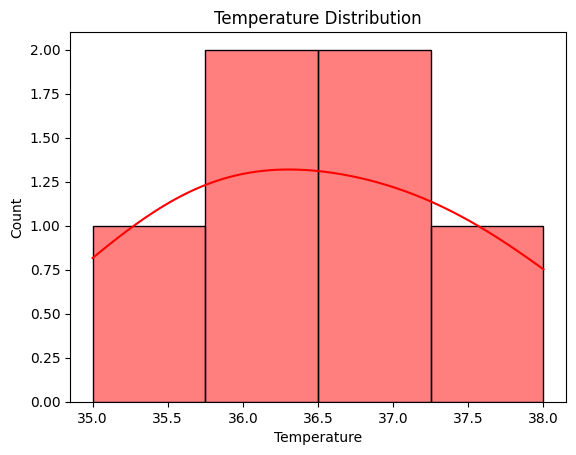

In [118]:
#Temperature Distribution

sns.histplot(vitals['Temperature'], kde=True,color='red')
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.show()

#This shows distribution of patient body temperatures and helps identify abnormal ranges

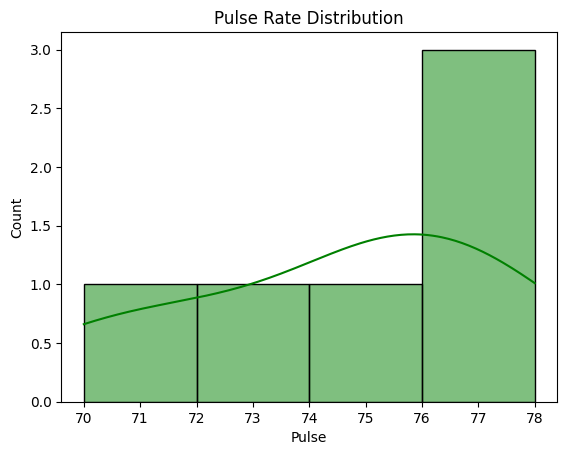

In [119]:
#Pulse Distribution

sns.histplot(vitals['Pulse'],kde=True,color='green')
plt.title("Pulse Rate Distribution")
plt.xlabel("Pulse")
plt.show()

#This helps analyze patient heart rate patterns.

In [120]:
#BP Distribution

vitals[['systolic', 'diastolic']] = vitals['BP'].str.split('/', expand=True)

vitals['systolic'] = vitals['systolic'].astype(int)
vitals['diastolic'] = vitals['diastolic'].astype(int)

#Blood pressure was split into systolic and diastolic values for better analysis

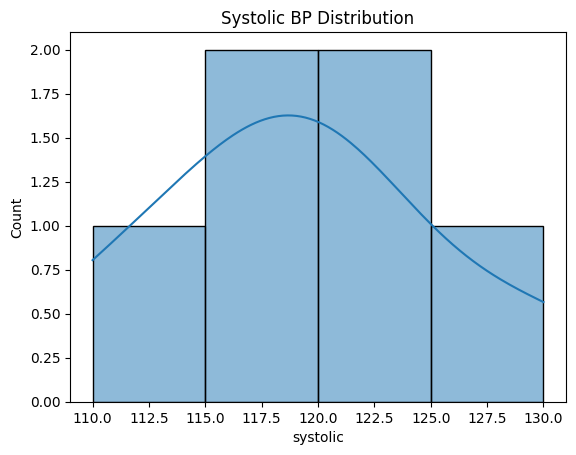

In [121]:
#Systolic BP

sns.histplot(vitals['systolic'], kde=True)
plt.title("Systolic BP Distribution")
plt.show()

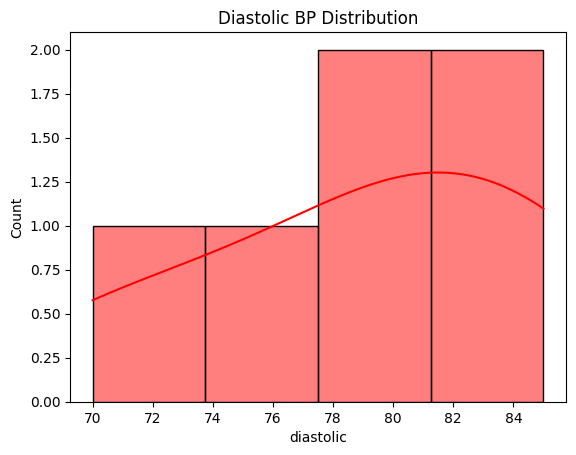

In [122]:
#Diastolic BP

sns.histplot(vitals['diastolic'], kde=True,color='red')
plt.title("Diastolic BP Distribution")
plt.show()



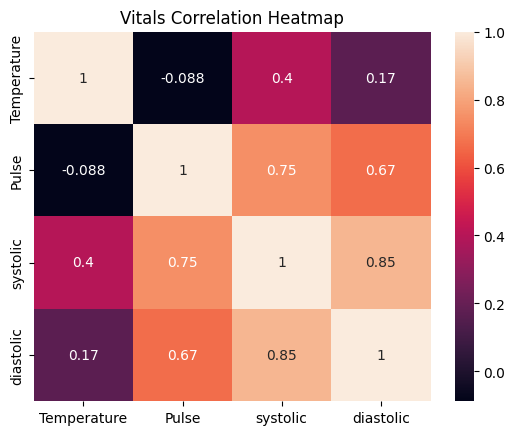

In [123]:
#Correlation Heatmap

sns.heatmap(vitals[['Temperature','Pulse','systolic','diastolic']].corr(), annot=True)
plt.title("Vitals Correlation Heatmap")
plt.show()

#Heatmap shows correlation between different vital parameters

#### PRESCRIPTIONS DATASET

In [124]:
prescriptions

,Prescription_id,Patient_id,Doctor_id,Medicine,Dosage,Instructions,Prescribed_at,Fulfilled
0,PR001,P001,UD001,Paracetamol 500mg,1 tablet twice daily,Take after food,2026-03-22 09:00:00,True
1,PR002,P002,UD002,Metformin 850mg,1 tablet daily,Take before breakfast,2026-03-23 10:30:00,True
2,PR003,P003,UD003,Ibuprofen 400mg,1 tablet twice daily,Take after meals,2026-03-24 11:00:00,False
3,PR004,P004,UD004,Omeprazole 20mg,1 capsule daily,Take before food,2026-03-26 14:00:00,True
4,PR005,P008,UD006,Cyclobenzaprine 10mg,1 tablet at night,Avoid driving after taking,2026-03-29 09:45:00,False
5,PR006,P010,UD005,Mucinex 600mg,1 tablet twice daily,Drink plenty of water,2026-03-29 13:15:00,True


In [125]:
#STRUCTURE

prescriptions.info()

#Checked structure including medicine, dosage, and dates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Prescription_id  6 non-null      object
 1   Patient_id       6 non-null      object
 2   Doctor_id        6 non-null      object
 3   Medicine         6 non-null      object
 4   Dosage           6 non-null      object
 5   Instructions     6 non-null      object
 6   Prescribed_at    6 non-null      object
 7   Fulfilled        6 non-null      bool  
dtypes: bool(1), object(7)
memory usage: 474.0+ bytes


In [126]:
prescriptions.isnull().sum()

,0
Prescription_id,0
Patient_id,0
Doctor_id,0
Medicine,0
Dosage,0
Instructions,0
Prescribed_at,0
Fulfilled,0


In [127]:
prescriptions.duplicated().sum()

np.int64(0)

##### VISUALIZATION

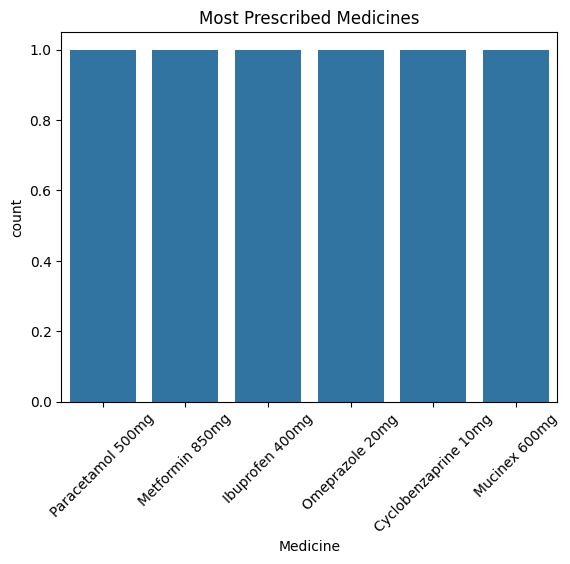

In [128]:
#Most Prescribed Medicines

sns.countplot(x='Medicine', data=prescriptions)
plt.title("Most Prescribed Medicines")
plt.xticks(rotation=45)
plt.show()

#This shows frequency of prescribed medicines, helping identify common treatments

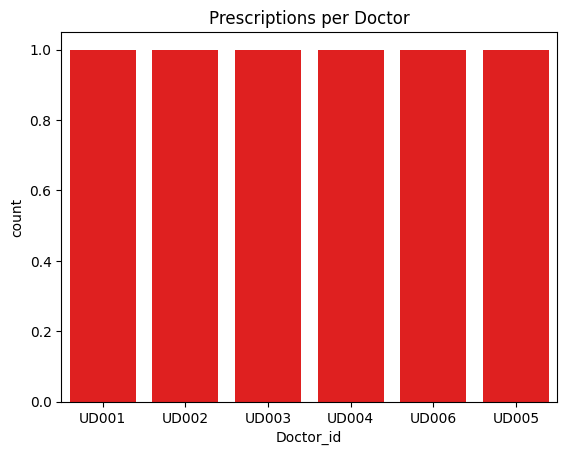

In [129]:
#Prescriptions per Doctor

sns.countplot(x='Doctor_id', data=prescriptions,color='red')
plt.title("Prescriptions per Doctor")
plt.show()

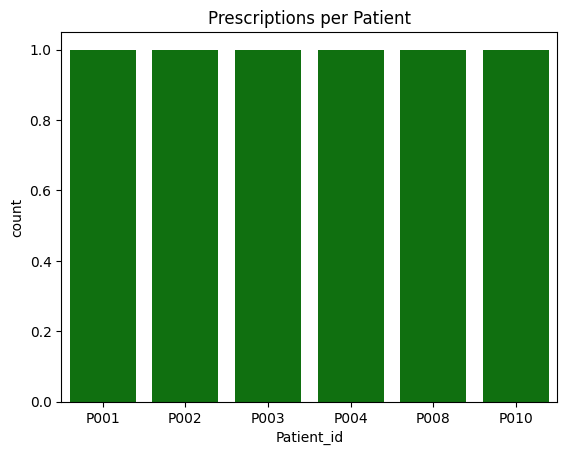

In [130]:
#Prescriptions per Patient

sns.countplot(x='Patient_id', data=prescriptions,color='green')
plt.title("Prescriptions per Patient")
plt.show()

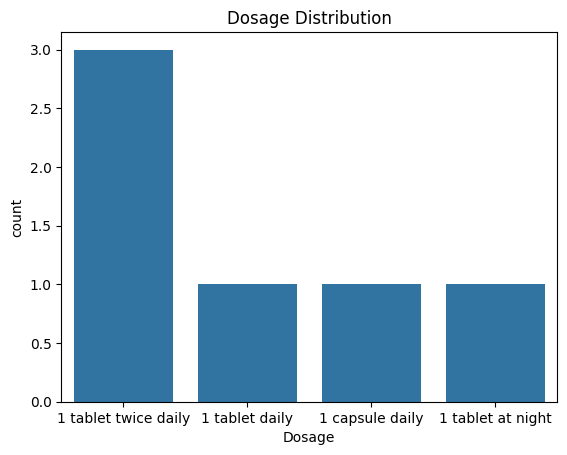

In [131]:
#Dosage Distribution

sns.countplot(x='Dosage', data=prescriptions)
plt.title("Dosage Distribution")
plt.show()

#### USERS DATASET

In [132]:
users

,User_id,Name,Role,Email,Phone
0,U001,Arjun,Patient,arjun@gmail.com,8902357822
1,U002,Meena,Patient,meena@gmail.com,9810328391
2,UD001,Dr.Kumar,Doctor,kumar@gmail.com,7589641258
3,UD002,Dr.Mehta,Doctor,mehta@gmail.com,6985321475
4,UN001,Priya,Nurse,priya@gmail.com,6325987412
5,UD004,Dr.Raj,Doctor,raj@gmail.com,9512364785
6,UD003,Dr.Prya,Doctor,priya.dr@gmail.com,6874512369
7,UD005,Dr.Roopa,Doctor,mehta@gmail.com,9658745236
8,UD006,Dr.Vivek,Doctor,vivek@gmail.com,9874569874
9,UD007,Dr.Anita,Doctor,anita@gmail.com,8974568459


In [133]:
#STRUCTURE

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   User_id  27 non-null     object
 1   Name     27 non-null     object
 2   Role     27 non-null     object
 3   Email    27 non-null     object
 4   Phone    27 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.2+ KB


In [134]:
users.duplicated().sum()

np.int64(0)

In [135]:
users.isnull().sum()

,0
User_id,0
Name,0
Role,0
Email,0
Phone,0


##### VISUALIZATION

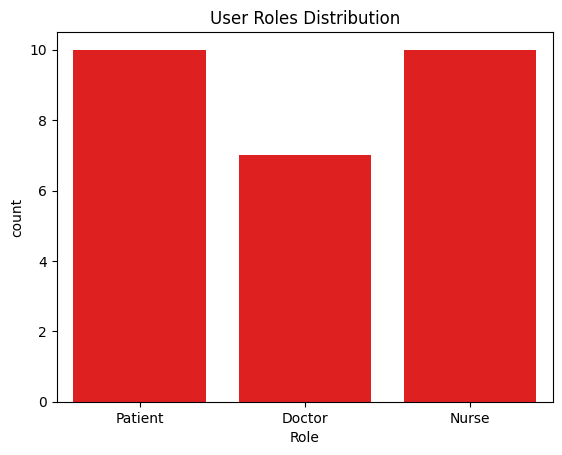

In [136]:
#ROLE DISTRIBUTION

sns.countplot(x='Role', data=users,color='red')
plt.title("User Roles Distribution")
plt.show()

#This shows distribution of roles like patients, doctors, and nurses in the system

#### Medical report

In [137]:
mr_df=medical_report
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,CBC: WBC 6200 RBC 4.5M Normal,2026-03-21 11:00:00
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,Mild infection in lungs,2026-03-21 11:15:00
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,No abnormalities detected,2026-03-21 11:30:00
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,High glucose level detected,2026-03-21 11:45:00
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,Lung inflammation observed,2026-03-21 12:00:00


In [138]:
mr_df.info()

#Checked structure of medical report dataset and verified column details

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Report_id       5 non-null      object
 1   Patient_id      5 non-null      object
 2   Uploaded_by     5 non-null      object
 3   Report_type     5 non-null      object
 4   File_url        5 non-null      object
 5   Extracted_text  5 non-null      object
 6   Uploaded_at     5 non-null      object
dtypes: object(7)
memory usage: 412.0+ bytes


In [139]:
mr_df.isnull().sum()

#Ensured medical_report data completeness

,0
Report_id,0
Patient_id,0
Uploaded_by,0
Report_type,0
File_url,0
Extracted_text,0
Uploaded_at,0


In [140]:
mr_df.duplicated().sum()

np.int64(0)

In [141]:
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,CBC: WBC 6200 RBC 4.5M Normal,2026-03-21 11:00:00
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,Mild infection in lungs,2026-03-21 11:15:00
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,No abnormalities detected,2026-03-21 11:30:00
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,High glucose level detected,2026-03-21 11:45:00
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,Lung inflammation observed,2026-03-21 12:00:00


In [142]:
mr_df['Report_type'].value_counts()

,count
Report_type,
Lab,2
X-ray,1
MRI,1
CT Scan,1


In [143]:
mr_df['Extracted_text'] = mr_df['Extracted_text'].str.lower().str.strip()
mr_df['Extracted_text']

#Since the dataset does not contain structured symptom columns, I used the extracted_text field, which contains medical findings from reports.
#I cleaned this text by converting it to lowercase and removing extra spaces to ensure consistency for analysis.

,Extracted_text
0,cbc: wbc 6200 rbc 4.5m normal
1,mild infection in lungs
2,no abnormalities detected
3,high glucose level detected
4,lung inflammation observed


In [144]:
keywords = {
    "diabetes": ["glucose", "sugar"],
    "infection": ["infection", "inflammation"],
    "normal": ["normal", "no abnormalities"]
}

#We define medical keywords to identify conditions from extracted text.
#Each category contains related terms that help in classification.

In [145]:
def extract_condition(text):
    for condition, words in keywords.items():
        for word in words:
            if word in text:
                return condition
    return "unknown"

#This function scans the extracted text and matches keywords to identify possible medical conditions.
#If no match is found, it returns "unknown".

In [146]:
organ_map = {
    "lung": "Pulmonologist",
    "brain": "Neurologist",
    "heart": "Cardiologist"
}

def extract_doctor(text, condition):
    text = text.lower()

    #organ-based detection
    for organ, doctor in organ_map.items():
        if organ in text:
            return doctor

    #condition-based fallback
    if condition == "diabetes":
        return "Endocrinologist"

    if condition == "infection":
        return "General Physician"

    return "General Physician"

In [147]:
mr_df['condition'] = mr_df['Extracted_text'].apply(extract_condition)
mr_df

#The function is applied to each row in the dataset to generate a new column called "condition",which represents the detected medical issue.

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection


#### EDA

In [148]:
mr_df['condition'].value_counts()

,count
condition,
normal,2
infection,2
diabetes,1


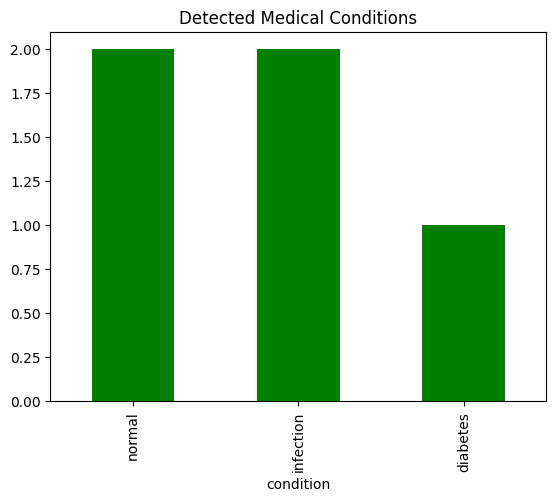

In [149]:
mr_df['condition'].value_counts().plot(kind='bar',color='green')
plt.title("Detected Medical Conditions")
plt.show()

#A bar chart is used to visually represent the distribution of detected conditions,making it easier to understand patterns.

In [150]:
#Mapping Condition

doctor_map = {
    "diabetes": "Endocrinologist",
    "infection": "General Physician",
    "normal": "General Physician",
    "unknown": "General Physician"
}

#Each detected condition is mapped to a suitable doctor type,forming the decision logic of the healthcare system.

In [151]:
#Apply Mapping

mr_df['recommended_doctor'] = mr_df.apply(
    lambda row: extract_doctor(row['Extracted_text'], row['condition']),
    axis=1
)
mr_df

#I used a two-level approach: first detecting medical conditions using keywords,
#then refining doctor recommendations using organ-level context from extracted text.

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition,recommended_doctor
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal,General Physician
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection,Pulmonologist
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal,General Physician
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes,Endocrinologist
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection,Pulmonologist


In [152]:
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition,recommended_doctor
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal,General Physician
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection,Pulmonologist
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal,General Physician
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes,Endocrinologist
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection,Pulmonologist


In [153]:
mr_df['Uploaded_at'] = pd.to_datetime(mr_df['Uploaded_at'])
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition,recommended_doctor
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal,General Physician
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection,Pulmonologist
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal,General Physician
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes,Endocrinologist
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection,Pulmonologist


#### Discharge_Summary

In [154]:
ds_df=discharge_summary
ds_df

,Discharge_id,Patient_id,Doctor_id,Summary_text,Created_at,Signed_at
0,DSC001,P001,UD001,3-day observation fever treated follow-up in 5...,2026-03-21 18:00:00,2026-03-21 18:10:00
1,DSC002,P002,UD002,Cardiac issue stabilized medication prescribed,2026-03-22 10:00:00,2026-03-22 10:15:00
2,DSC003,P003,UD003,Migraine treated advised rest and hydration,2026-03-22 11:30:00,2026-03-22 11:45:00
3,DSC004,P004,UD004,Acidity controlled diet changes recommended,2026-03-23 09:00:00,2026-03-23 09:10:00
4,DSC005,P008,UD006,Lung infection treated antibiotics prescribed,2026-03-23 12:00:00,2026-03-23 12:15:00


In [155]:
ds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Discharge_id  5 non-null      object
 1   Patient_id    5 non-null      object
 2   Doctor_id     5 non-null      object
 3   Summary_text  5 non-null      object
 4   Created_at    5 non-null      object
 5   Signed_at     5 non-null      object
dtypes: object(6)
memory usage: 372.0+ bytes


In [156]:
ds_df.isnull().sum()

,0
Discharge_id,0
Patient_id,0
Doctor_id,0
Summary_text,0
Created_at,0
Signed_at,0


In [157]:
ds_df.duplicated().sum()

np.int64(0)

In [158]:
ds_df['Created_at'] = pd.to_datetime(ds_df['Created_at'])
ds_df['Signed_at'] = pd.to_datetime(ds_df['Signed_at'])

#Converted timestamps into datetime format to enable time-based analysis such as report processing duration

In [159]:
ds_df

,Discharge_id,Patient_id,Doctor_id,Summary_text,Created_at,Signed_at
0,DSC001,P001,UD001,3-day observation fever treated follow-up in 5...,2026-03-21 18:00:00,2026-03-21 18:10:00
1,DSC002,P002,UD002,Cardiac issue stabilized medication prescribed,2026-03-22 10:00:00,2026-03-22 10:15:00
2,DSC003,P003,UD003,Migraine treated advised rest and hydration,2026-03-22 11:30:00,2026-03-22 11:45:00
3,DSC004,P004,UD004,Acidity controlled diet changes recommended,2026-03-23 09:00:00,2026-03-23 09:10:00
4,DSC005,P008,UD006,Lung infection treated antibiotics prescribed,2026-03-23 12:00:00,2026-03-23 12:15:00


In [160]:
ds_df['Summary_text'] = ds_df['Summary_text'].str.lower().str.strip()

#Cleaned discharge summary text to standardize formatting and prepare it for keyword-based analysis or NLP tasks

In [161]:
#Condition Extraction
keywords = {
    "cardiac": ["cardiac", "heart"],
    "migraine": ["migraine", "headache"],
    "acidity": ["acidity"],
    "lung": ["lung"],
    "infection": ["infection", "inflammation"],
    "fever": ["fever"],
    "diabetes": ["glucose", "sugar"],
    "normal": ["normal", "no abnormalities", "within normal limits"]
}

In [162]:

def extract_condition(text):
    text = str(text).lower()

    found_conditions = []

    for condition, words in keywords.items():
        for word in words:
            pattern = r'\b' + re.escape(word) + r'\b'
            if re.search(pattern, text):
                found_conditions.append(condition)

    # 🎯 PRIORITY LOGIC
    priority = ["migraine", "diabetes", "lung", "cardiac", "infection", "fever", "acidity", "normal"]

    for p in priority:
        if p in found_conditions:
            return p

    return "normal"

In [163]:
import re
text = "mild infection in lungs" # Example text to test
for condition, words in keywords.items():
    for word in words:
        pattern = r'\b' + re.escape(word) + r'\b'
        if re.search(pattern,text):
            print("MATCHED:", word, "→", condition)

MATCHED: infection → infection


In [164]:
def extract_doctor(text, condition):
    text = str(text).lower()

    if condition == "migraine":
        return "Neurologist"
    if condition == "diabetes":
        return "Endocrinologist"
    if condition == "lung":
        return "Pulmonologist"
    if condition == "cardiac":
        return "Cardiologist"
    if condition == "acidity":
        return "Gastroenterologist"
    if condition == "fever":
        return "General Physician"
    if condition == "infection":
        return "General Physician"
    if condition == "normal":
        return "General Physician"

    if "lung" in text:
        return "Pulmonologist"
    if "glucose" in text:
        return "Endocrinologist"

    return "General Physician"

In [165]:
ds_df['condition'] = ds_df['Summary_text'].apply(extract_condition)

#Extracted medical conditions from discharge summaries using keyword matching.
#This helps identify patient diagnoses automatically.

In [166]:
ds_df[['Summary_text', 'condition']]

,Summary_text,condition
0,3-day observation fever treated follow-up in 5...,fever
1,cardiac issue stabilized medication prescribed,cardiac
2,migraine treated advised rest and hydration,migraine
3,acidity controlled diet changes recommended,acidity
4,lung infection treated antibiotics prescribed,lung


In [167]:
#Mapping
doctor_map = {
    "cardiac": "Cardiologist",
    "migraine": "Neurologist",
    "acidity": "Gastroenterologist",
    "lung": "Pulmonologist",
    "infection": "General Physician",
    "fever": "General Physician",
    "brain": "Neurologist",
    "heart": "Cardiologist",
    "diabetes": "Endocrinologist",
    "unknown": "General Physician"
}

In [168]:
ds_df['recommended_doctor'] = ds_df['condition'].map(doctor_map)

##Based on extracted conditions, appropriate doctors are recommended,enabling automated healthcare decision support.

In [169]:
ds_df

,Discharge_id,Patient_id,Doctor_id,Summary_text,Created_at,Signed_at,condition,recommended_doctor
0,DSC001,P001,UD001,3-day observation fever treated follow-up in 5...,2026-03-21 18:00:00,2026-03-21 18:10:00,fever,General Physician
1,DSC002,P002,UD002,cardiac issue stabilized medication prescribed,2026-03-22 10:00:00,2026-03-22 10:15:00,cardiac,Cardiologist
2,DSC003,P003,UD003,migraine treated advised rest and hydration,2026-03-22 11:30:00,2026-03-22 11:45:00,migraine,Neurologist
3,DSC004,P004,UD004,acidity controlled diet changes recommended,2026-03-23 09:00:00,2026-03-23 09:10:00,acidity,Gastroenterologist
4,DSC005,P008,UD006,lung infection treated antibiotics prescribed,2026-03-23 12:00:00,2026-03-23 12:15:00,lung,Pulmonologist


In [170]:
def generate_response(text):
    text = text.lower()

    #condition detection
    condition = extract_condition(text)

    #doctor recommendation
    doctor = extract_doctor(text, condition)

    #response generation
    response = f"""
    🩺 Medical Analysis Result:

    Detected Condition: {condition.upper()}

    Recommended Doctor: {doctor}

    Advice:
    Please consult the recommended doctor for further evaluation.
    """

    return response

#This function simulates an AI healthcare assistant by taking medical text as input and generating structured output including condition and doctor recommendation.

In [171]:
print(generate_response("lung infection treated with antibiotics"))
print(generate_response("high glucose level detected"))
print(generate_response("migraine and headache issues"))


    🩺 Medical Analysis Result:

    Detected Condition: LUNG

    Recommended Doctor: Pulmonologist

    Advice:
    Please consult the recommended doctor for further evaluation.
    

    🩺 Medical Analysis Result:

    Detected Condition: DIABETES

    Recommended Doctor: Endocrinologist

    Advice:
    Please consult the recommended doctor for further evaluation.
    

    🩺 Medical Analysis Result:

    Detected Condition: MIGRAINE

    Recommended Doctor: Neurologist

    Advice:
    Please consult the recommended doctor for further evaluation.
    


EDA

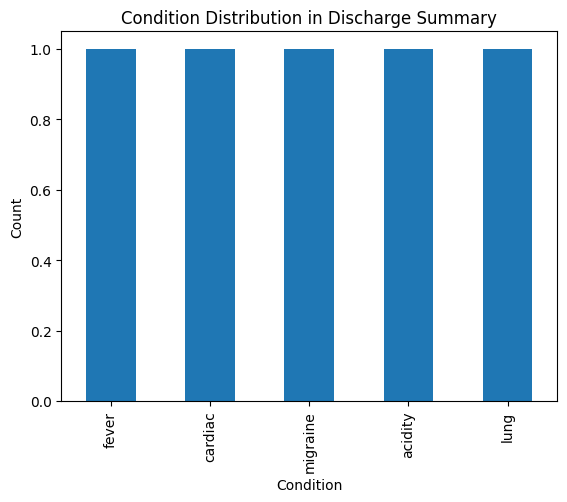

In [172]:
import matplotlib.pyplot as plt

ds_df['condition'].value_counts().plot(kind='bar')
plt.title("Condition Distribution in Discharge Summary")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

#Visualizes the distribution of medical conditions for better understanding of trends.

#### ADMINS

In [173]:
admin_df=admin
admin_df

,Log_id,User_id,Action,Target_entity,Timestamp,Details
0,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels
1,LOG002,UD020,Updated schedule,Doctor,2026-03-21 21:10:00,Adjusted Dr.Kumar availability
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,Accessed records of P001
3,LOG004,UD020,Generated report,Reports,2026-03-21 21:30:00,Created daily patient summary
4,LOG005,UD020,Updated inventory,Inventory,2026-03-21 21:40:00,Added 500 units of medicine stock


In [174]:
admin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Log_id         5 non-null      object
 1   User_id        5 non-null      object
 2   Action         5 non-null      object
 3   Target_entity  5 non-null      object
 4   Timestamp      5 non-null      object
 5   Details        5 non-null      object
dtypes: object(6)
memory usage: 372.0+ bytes


In [175]:
admin_df.isnull().sum()

#Verified that there are no missing values to ensure reliable administrative data.

,0
Log_id,0
User_id,0
Action,0
Target_entity,0
Timestamp,0
Details,0


In [176]:
admin_df.duplicated().sum()

#Checked for duplicate admin records to maintain data integrity and avoid redundancy.

np.int64(0)

In [177]:
admin_df.describe()

,Log_id,User_id,Action,Target_entity,Timestamp,Details
count,5,5,5,5,5,5
unique,5,1,5,4,5,5
top,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels
freq,1,5,1,2,1,1


In [178]:
admin_df['Timestamp'] = pd.to_datetime(admin_df['Timestamp'])

#Converted timestamp column into datetime format to enable time-based analysis of system activities.

In [179]:
admin_df['hour'] = admin_df['Timestamp'].dt.hour
admin_df

#Extracted hour from timestamp to analyze peak system usage times

,Log_id,User_id,Action,Target_entity,Timestamp,Details,hour
0,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels,21
1,LOG002,UD020,Updated schedule,Doctor,2026-03-21 21:10:00,Adjusted Dr.Kumar availability,21
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,Accessed records of P001,21
3,LOG004,UD020,Generated report,Reports,2026-03-21 21:30:00,Created daily patient summary,21
4,LOG005,UD020,Updated inventory,Inventory,2026-03-21 21:40:00,Added 500 units of medicine stock,21


In [180]:
admin_df['date'] = admin_df['Timestamp'].dt.date
admin_df

#Extracted date to analyze daily activity trends.

,Log_id,User_id,Action,Target_entity,Timestamp,Details,hour,date
0,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels,21,2026-03-21
1,LOG002,UD020,Updated schedule,Doctor,2026-03-21 21:10:00,Adjusted Dr.Kumar availability,21,2026-03-21
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,Accessed records of P001,21,2026-03-21
3,LOG004,UD020,Generated report,Reports,2026-03-21 21:30:00,Created daily patient summary,21,2026-03-21
4,LOG005,UD020,Updated inventory,Inventory,2026-03-21 21:40:00,Added 500 units of medicine stock,21,2026-03-21


In [181]:
admin_df['Details'] =admin_df['Details'].str.lower().str.strip()

In [182]:
def extract_activity(text):
    if "stock" in text:
        return "Inventory Check"
    elif "availability" in text:
        return "Schedule Update"
    elif "records" in text:
        return "Patient Access"
    elif "report" in text:
        return "Report Generation"
    else:
        return "Other"

admin_df['activity_type'] = admin_df['Details'].apply(extract_activity)

#Extracted meaningful categories from unstructured log details to better understand system usage patterns.

EDA

In [183]:
admin_df['Action'].value_counts()

#Shows the most frequent actions performed by admins, such as inventory updates or patient data access.

,count
Action,
Checked inventory,1
Updated schedule,1
Viewed patient data,1
Generated report,1
Updated inventory,1


In [184]:
admin_df['Target_entity'].value_counts()

,count
Target_entity,
Inventory,2
Doctor,1
Patient,1
Reports,1


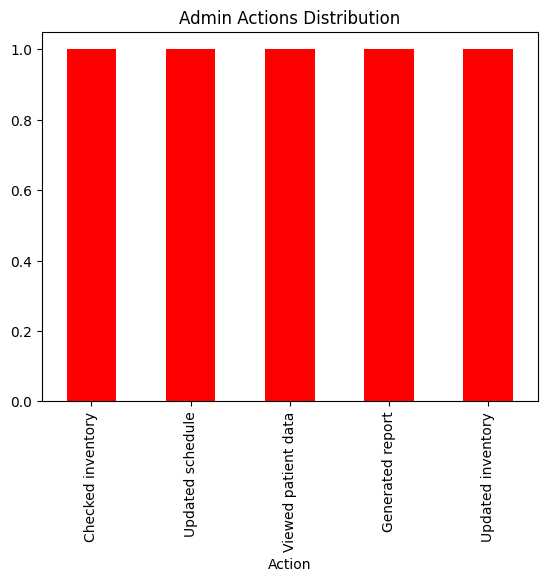

In [185]:
import matplotlib.pyplot as plt

admin_df['Action'].value_counts().plot(kind='bar',color='red')
plt.title("Admin Actions Distribution")
plt.show()

#Visual representation of admin activities helps quickly understand system usage patterns.

In [186]:
admin_df[admin_df['Action'].str.contains("Viewed patient data")]

#Helps track sensitive operations like patient data access for security and compliance.

,Log_id,User_id,Action,Target_entity,Timestamp,Details,hour,date,activity_type
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,accessed records of p001,21,2026-03-21,Patient Access


##### NLP

In [187]:
combined_text = pd.concat([
    mr_df['Extracted_text'],
    ds_df['Summary_text']
]).reset_index(drop=True)

combined_df = pd.DataFrame({"text": combined_text})

combined_df
#Combined medical reports and discharge summaries into a single dataset to create a unified text source for model training.


,text
0,cbc: wbc 6200 rbc 4.5m normal
1,mild infection in lungs
2,no abnormalities detected
3,high glucose level detected
4,lung inflammation observed
5,3-day observation fever treated follow-up in 5...
6,cardiac issue stabilized medication prescribed
7,migraine treated advised rest and hydration
8,acidity controlled diet changes recommended
9,lung infection treated antibiotics prescribed


In [217]:
import re
def clean_text(text):
    text = str(text).lower()

    # remove doctor names
    text = re.sub(r'dr\.\s*\w+\s*\w*', '', text)
    text = re.sub(r'general physician', '', text)
    text = re.sub(r'[^a-z0-9\s/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

combined_df['text'] = combined_df['text'].apply(clean_text)

#Converted text to lowercase and normalized whitespace while preserving important medical patterns such as numbers and symbols.

In [218]:
keywords = {
    "migraine": ["migraine", "headache"],
    "diabetes": ["glucose", "sugar"],
    "lung": ["lung"],
    "cardiac": ["cardiac", "heart"],
    "infection": ["infection", "inflammation"],
    "fever": ["fever"],
    "acidity": ["acidity"],
    "normal": ["normal", "no abnormalities"]
}

In [219]:
def extract_condition(text):
    text = str(text).lower()
    found = []

    for condition, words in keywords.items():
        for word in words:
            if re.search(r'\b' + word + r'\b', text):
                found.append(condition)

    priority = ["migraine","diabetes","lung","cardiac","infection","fever","acidity","normal"]

    for p in priority:
        if p in found:
            return p

    return "normal"

    # Medical conditions are identified using keyword matching with regex (exact word matching).
    #Multiple matches are handled using priority logic.

In [220]:
def extract_doctor(text, condition):

    if condition == "migraine":
        return "Neurologist"
    elif condition == "diabetes":
        return "Endocrinologist"
    elif condition == "lung":
        return "Pulmonologist"
    elif condition == "cardiac":
        return "Cardiologist"
    elif condition == "acidity":
        return "Gastroenterologist"
    else:
        return "General Physician"

#Doctors are assigned based on detected condition using predefined mappings.

In [222]:
combined_df['condition'] = combined_df['text'].apply(extract_condition)

combined_df['recommended_doctor'] = combined_df.apply(
    lambda row: extract_doctor(row['text'], row['condition']),
    axis=1
)

combined_df

,text,condition,recommended_doctor
0,cbc wbc 6200 rbc 45m normal,normal,General Physician
1,mild infection in lungs,infection,General Physician
2,no abnormalities detected,normal,General Physician
3,high glucose level detected,diabetes,Endocrinologist
4,lung inflammation observed,lung,Pulmonologist
5,3day observation fever treated followup in 5 days,fever,General Physician
6,cardiac issue stabilized medication prescribed,cardiac,Cardiologist
7,migraine treated advised rest and hydration,migraine,Neurologist
8,acidity controlled diet changes recommended,acidity,Gastroenterologist
9,lung infection treated antibiotics prescribed,lung,Pulmonologist


#### VECTORIZATION

In [240]:
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(combined_df['text'])

#Text data cannot be directly used by machine learning models. So we convert text into numerical form
#using CountVectorizer, which creates a matrix based on word frequency.


##### ML

In [241]:
model = MultinomialNB()
model.fit(X, combined_df['recommended_doctor'])

#A Multinomial Naive Bayes model is trained to predict doctor recommendations from text.

MultinomialNB()

In [227]:
def predict_doctor(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]



In [229]:
def final_prediction(text):
    text = clean_text(text)

    condition = extract_condition(text)
    doctor = extract_doctor(text, condition)

    return f"""
Condition: {condition.upper()}
Recommended Doctor: {doctor}
"""
#A function is created to:Clean input text,Convert to vector,Predict doctor.

#Due to limited dataset size, ML accuracy is low, so I relied on rule-based logic for final predictions.

In [203]:
print(final_prediction("migraine headache"))
print(final_prediction("high glucose"))
print(final_prediction("lung infection"))


    Condition: MIGRAINE

    Recommeded Doctor: Neurologist)
    

    Condition: DIABETES

    Recommeded Doctor: Endocrinologist)
    

    Condition: LUNG

    Recommeded Doctor: Pulmonologist)
    


In [244]:
X = vectorizer.fit_transform(combined_df['text'])
y = combined_df['recommended_doctor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.0
                    precision    recall  f1-score   support

   Endocrinologist       0.00      0.00      0.00       0.0
Gastroenterologist       0.00      0.00      0.00       1.0
 General Physician       0.00      0.00      0.00       1.0
     Pulmonologist       0.00      0.00      0.00       0.0

          accuracy                           0.00       2.0
         macro avg       0.00      0.00      0.00       2.0
      weighted avg       0.00      0.00      0.00       2.0



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [251]:
X = vectorizer.fit_transform(combined_df['text'])
y = combined_df['recommended_doctor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_rf = RandomForestClassifier(class_weight='balanced')
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5
                    precision    recall  f1-score   support

Gastroenterologist       0.00      0.00      0.00         1
 General Physician       0.50      1.00      0.67         1

          accuracy                           0.50         2
         macro avg       0.25      0.50      0.33         2
      weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
X = vectorizer.fit_transform(combined_df['text'])
y = combined_df['recommended_doctor']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_rf = RandomForestClassifier(class_weight='balanced')
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Performance is limited due to small dataset size
#Rule-based system provides more reliable results

### OCR

In [204]:
!apt-get update
!apt-get install -y tesseract-ocr
!pip install pytesseract pillow

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,972 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,622 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,219 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,125 kB]
Get:14 https://r2u.

In [232]:
import pytesseract
from PIL import Image

def extract_text_from_image(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

#Medical report images are converted into text using Tesseract OCR.

In [233]:
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'
print(pytesseract.get_tesseract_version())

4.1.1


In [234]:
text = extract_text_from_image("medical_report.png")
print(text)

& +1 (555) 123-4567
& info@cityhealthmc.org
Y 123 Wellness Street, Healthy City, HC 12345

pills, CITY HEALTH

MEDICAL CENTER

 

MEDICAL REPORT

Date: April 24, 2024

PATIENT INFORMATION
Name: John Michael Doe
Patient ID: CHMC-2024-1058
Date of Birth: May 14, 1985

: +1 (555) 987-6543
doe@email.com
Address: 456 Oak Avenue,

  

 

 

Age: 38 years Healthy City, HC 12345
Gender: Male Date of April 24, 2024
(CHIEF COMPLAINT

Patient presented with complaints of persistent headache, fatigue, and mild dizziness for the past 5 days.

 

 

VITAL SIGNS
Blood Pressure: Heart Rate: Temperature: Respiratory Rate: SpO,:
128/82 mmHg 78 bpm 98.6 °F (37 °C) 16 breaths/min 99%
HISTORY

No significant past medical history. Denies any chronic illnesses, recent travel, or sick contacts. Not currently
on any medications. No known allergies.

PHYSICAL EXAMINATION

General: Patient is alert, oriented, and in no acute distress.

HEENT: Mild tenderness over the frontal region. No sinus congestion. Throat c

##### RAG

In [235]:
patient_memory = {
    "P001": "Had fever and headache last week",
    "P002": "High BP patient",
    "P003": "Diabetes patient"
}

def get_patient_history(patient_id):
    return patient_memory.get(patient_id, "No history found")

#Patient history is retrieved using a simple dictionary-based retrieval system.

In [242]:
def chatbot_system(user_input=None, image_path=None, patient_id=None):

    if image_path:
        text = extract_text_from_image(image_path)
    else:
        text = user_input

    result = final_prediction(text)

    history = get_patient_history(patient_id) if patient_id else "No history"

    return f"""
CareConnect AI Result

{result}

Patient History:
{history}
"""

#All components are integrated:
  # *Text input OR image input
  # *NLP processing
  # *Doctor recommendation
  # *Patient history

In [237]:
print(chatbot_system(user_input="migraine headache", patient_id="P001"))


CareConnect AI Result


    Condition: MIGRAINE

    Recommeded Doctor: Neurologist)
    

Patient History:
Had fever and headache last week



In [239]:
print(chatbot_system(image_path="medical_report.png", patient_id="P002"))


CareConnect AI Result


    Condition: MIGRAINE

    Recommeded Doctor: Neurologist)
    

Patient History:
High BP patient



In [ ]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

In [215]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("careconnect.db")

df = pd.read_sql("SELECT * FROM vitals", conn)
print(df)

conn.close()

DatabaseError: Execution failed on sql 'SELECT * FROM vitals': no such table: vitals

#### ocr.py


In [4]:
%%writefile ocr.py
from PIL import Image
import pytesseract

# For Colab / Linux
pytesseract.pytesseract.tesseract_cmd = '/usr/bin/tesseract'

def extract_text_from_image(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

Overwriting ocr.py


#### rag.py

In [6]:
%%writefile rag.py
# Patient memory (mock data)

patient_memory = {
    "P001": "Had fever and headache last week",
    "P002": "High BP patient",
    "P003": "Diabetes patient"
}


def get_patient_history(patient_id):
    return patient_memory.get(patient_id, "No history found")

Writing rag.py


#### backend.py

In [8]:
%%writefile backend.py
def save_report(patient_id, bp, temperature):
    conn = create_connection()
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS reports (
        patient_id TEXT,
        bp TEXT,
        temperature TEXT
    )
    """)

    cursor.execute("""
    INSERT INTO reports (patient_id, bp, temperature)
    VALUES (?, ?, ?)
    """, (patient_id, bp, temperature))

    conn.commit()
    conn.close()

Overwriting backend.py


#### database.py

In [9]:
%%writefile backend.py
import sqlite3
import pandas as pd

def create_connection():
    conn = sqlite3.connect("careconnect.db")
    return conn

def create_tables():
    conn = create_connection()
    cursor = conn.cursor()


    # Users Table
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS users (
        user_id TEXT PRIMARY KEY,
        name TEXT,
        role TEXT
    )
    """)

    # Patients Table
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS patients (
        patient_id TEXT PRIMARY KEY,
        user_id TEXT,
        age INTEGER,
        gender TEXT,
        blood_group TEXT,
        allergies TEXT,
        medical_history TEXT
    )
    """)

    # Doctors Table
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS doctors (
        doctor_id TEXT PRIMARY KEY,
        name TEXT,
        specialization TEXT,
        available_time TEXT
    )
    """)

    # Appointments Table
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS appointments (
        appointment_id TEXT PRIMARY KEY,
        patient_id TEXT,
        doctor_id TEXT,
        date TEXT,
        status TEXT
    )
    """)

    # Vitals Table
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS vitals (
        patient_id TEXT,
        temperature REAL,
        bp TEXT,
        pulse INTEGER
    )
    """)

    # Prescriptions Table
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS prescriptions (
        prescription_id TEXT PRIMARY KEY,
        patient_id TEXT,
        doctor_id TEXT,
        medicine TEXT,
        dosage TEXT,
        date TEXT
    )
    """)

    conn.commit()
    conn.close()

# ✅ INSERT DATA FUNCTION
def insert_data():
    conn = create_connection()

    users = pd.read_csv("Users.csv")
    patients = pd.read_csv("Patients_table.csv")
    doctors = pd.read_csv("Doctors_table.csv")
    appointments = pd.read_csv("Appointments.csv")
    vitals = pd.read_csv("Vitals.csv")
    prescriptions = pd.read_csv("Prescription.csv")

    users.to_sql("users", conn, if_exists="replace", index=False)
    patients.to_sql("patients", conn, if_exists="replace", index=False)
    doctors.to_sql("doctors", conn, if_exists="replace", index=False)
    appointments.to_sql("appointments", conn, if_exists="replace", index=False)
    vitals.to_sql("vitals", conn, if_exists="replace", index=False)
    prescriptions.to_sql("prescriptions", conn, if_exists="replace", index=False)

    conn.close()

# ✅ MAIN EXECUTION
if __name__ == "__main__":
    create_tables()
    insert_data()

Overwriting backend.py


####chatbot.py

In [1]:
%%writefile chatbot.py
import re

# 🔹 Clean Text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s/]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# 🔹 Keywords
keywords = {
    "cardiac": ["cardiac", "heart"],
    "migraine": ["migraine", "headache"],
    "acidity": ["acidity"],
    "lung": ["lung"],
    "infection": ["infection", "inflammation"],
    "fever": ["fever"],
    "diabetes": ["glucose", "sugar"],
    "normal": ["normal", "no abnormalities"]
}


# 🔹 Condition Detection
def extract_condition(text):
    text = clean_text(text)

    for condition, words in keywords.items():
        for word in words:
            if re.search(r'\b' + word + r'\b', text):
                return condition

    return "normal"


# 🔹 Doctor Mapping
doctor_map = {
    "cardiac": "Cardiologist",
    "migraine": "Neurologist",
    "acidity": "Gastroenterologist",
    "lung": "Pulmonologist",
    "infection": "General Physician",
    "fever": "General Physician",
    "diabetes": "Endocrinologist",
    "normal": "General Physician"
}


# 🔹 Final Prediction
def final_prediction(text):
    text = clean_text(text)

    condition = extract_condition(text)
    doctor = doctor_map.get(condition, "General Physician")

    return f"""
🩺 CareConnect AI Result

Condition: {condition.upper()}

Recommended Doctor: {doctor}
"""

Writing chatbot.py


#STREAMLIT

In [ ]:
!pip install streamlit

In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
from ai_engine import final_prediction
from ocr_engine import extract_text_from_image
from rag_engine import get_patient_history

st.set_page_config(
    page_title="CareConnect AI",
    page_icon="🩺",
    layout="wide"
)

st.markdown("""
<style>

/* MAIN BACKGROUND */
[data-testid="stAppViewContainer"] {
    background-color: #0e1117;
    color: white;
}

/* SIDEBAR */
[data-testid="stSidebar"] {
    background: #1a1c23;
}

/* SIDEBAR TEXT */
[data-testid="stSidebar"] * {
    color: white!important;
}

/* MAIN TEXT ONLY */
[data-testid="stAppViewContainer"] {
    color: white;
}

/* LABELS */
label {
    color: white !important;
}

/* HEADINGS */
h1, h2, h3 {
    color: #c77dff !important;
}

/* SELECT BOX (Navigation) */
div[data-baseweb="select"] > div {
    background-color: #7b2cbf !important;
    color: white !important;
    border-radius: 10px;
}

/* INPUT BOXES */
input, textarea {
    background-color: #1e1e2f !important;
    color: white !important;
    border: 1px solid #7b2cbf !important;
}

/* BUTTON */
.stButton>button {
    background-color: #9d4edd;
    color: white;
    border-radius: 10px;
    height: 3em;
    font-size: 16px;
}

/* BUTTON HOVER */
.stButton>button:hover {
    background-color: #c77dff;
    transform: scale(1.05);
}

/* HEADINGS */
h1, h2, h3 {
    color: #c77dff;
}

/* CARD STYLE */
.card {
    background-color: #1e1e2f;   /* dark card */
    color:#1e1e2f;
    padding: 10px;
    border-radius: 15px;
    box-shadow: 0px 4px 20px rgba(0,0,0,0.5);
    margin-bottom: 20px;
}

/* SUCCESS */
.stSuccess {
    background-color: #1b5e20 !important;
    color: white;
}

/* WARNING */
.stWarning {
    background-color: #ff6f00 !important;
    color: white;
}

/* ERROR */
.stError {
    background-color: #b71c1c !important;
    color: white;
}

/* REMOVE TOP WHITE BAR */
header {
    visibility: hidden;
}


</style>
""", unsafe_allow_html=True)

st.markdown("""
<h1 style='text-align: center;'>🩺 CareConnect AI</h1>
<h4 style='text-align: center;'>Smart Healthcare Assistant</h4>
<hr>
""", unsafe_allow_html=True)


menu = ["Chatbot", "View Doctors", "Book Appointment", "Add Vitals","Dashboard","Patient Details","Prescriptions","Upload Report"]
choice = st.sidebar.selectbox("Select Option", menu)

# CHATBOT
if choice == "Chatbot":

    st.subheader("🧠 AI Health Assistant")

    user_input = st.text_area("Describe your symptoms:")

    # 👉 Store response
    if "chat_response" not in st.session_state:
        st.session_state.chat_response = None

    # 🔥 First button
    if st.button("Get Suggestion"):

      if user_input.strip() == "":
        st.warning("Please enter symptoms")
      else:
        result = final_prediction(user_input)
        st.success(result)

    # 👉 SHOW RESPONSE AFTER BUTTON CLICK
    if st.session_state.chat_response:

        response = st.session_state.chat_response

        st.success(response["message"])

        if response.get("doctor"):

            # 🔥 SECOND BUTTON (NOW WORKS)
            if st.button(f"Book Appointment with {response['doctor']}"):

                import datetime
                import random

                doctor_map = {
                    "General Physician": "D001",
                    "Cardiologist": "D002",
                    "Neurologist": "D003",
                    "Orthopedic": "D004",
                    "Gastroenterologist": "D005"
                }

                appointment_id = "A" + str(random.randint(100, 999))
                patient_id = "P001"
                doctor_id = doctor_map.get(response["doctor"], "D001")
                date = datetime.date.today()

                book_appointment(appointment_id, patient_id, doctor_id, date)

                st.success("✅ Appointment booked successfully!")
                st.write(f"Doctor: {response['doctor']}")
                st.write(f"Date: {date}")

#VIEW DOCTORS
elif choice == "View Doctors":
    st.header("Available Doctors")

    doctors = view_doctors()

    df = pd.DataFrame(doctors, columns=["Doctor ID","Name","Specialization","Available Time"])
    st.dataframe(df, use_container_width=True)

    st.markdown('</div>', unsafe_allow_html=True)

#BOOK APPOINTMENTS
elif choice == "Book Appointment":
    st.subheader("📅 Book Appointment")

    col1, col2 = st.columns(2)

    with col1:
        appointment_id = st.text_input("Appointment ID")
        patient_id = st.text_input("Patient ID")

    with col2:
        doctor_id = st.text_input("Doctor ID")
        date = st.date_input("Select Date")

    if st.button("Book Appointment"):
        if appointment_id and patient_id and doctor_id:
            book_appointment(appointment_id, patient_id, doctor_id, str(date))
            st.success("✅ Appointment booked successfully!")
        else:
            st.error("Please fill all fields")

# ADD VITALS
elif choice == "Add Vitals":

    st.markdown("""
<div style='padding:1px; background-color:#dfe391; border-radius:10px;'>
<h2 style='font-size:20px; color:#c77dff;'>❤️ Add Patient Vitals</h2>
</div>
""", unsafe_allow_html=True)

    col1, col2 = st.columns(2)

    with col1:
        patient_id = st.text_input("Patient ID", key="vitals_patient")
        temperature = st.number_input("Temperature", key="vitals_temp")

    with col2:
        bp = st.text_input("Blood Pressure (e.g., 120/80)", key="vitals_bp")
        pulse = st.number_input("Pulse", key="vitals_pulse")

    if st.button("Save Vitals"):

        if not patient_id:
            st.error("Enter patient ID")

        elif temperature < 30 or temperature > 45:
            st.error("⚠️ Temperature seems abnormal")

        elif pulse < 40 or pulse > 150:
            st.error("⚠️ Pulse seems abnormal")

        else:
            add_vitals(patient_id, temperature, bp, pulse)

            st.success("✅ Vitals added successfully!")

            # 🔥 AI RISK
            risk = predict_risk(temperature, bp, pulse)

            if risk == "HIGH RISK":
                st.error("🚨 HIGH RISK detected! Immediate attention needed")

            elif risk == "MILD RISK":
                st.warning("⚠️ Mild Risk detected")

            else:
                st.success("✅ Patient is Normal")

#DASHBOARD
elif choice == "Dashboard":

    st.markdown("## 📊 Healthcare Dashboard")

    import sqlite3
    conn = sqlite3.connect("careconnect.db")

    patients = pd.read_sql("SELECT * FROM patients", conn)
    appointments = pd.read_sql("SELECT * FROM appointments", conn)

    col1, col2 = st.columns(2)

    with col1:
        st.metric("👨‍⚕️ Total Patients", len(patients))

    with col2:
        st.metric("📅 Total Appointments", len(appointments))

    st.write("### 📊 Disease Distribution")
    if not patients.empty:
        st.bar_chart(patients['Medical_history'].value_counts())

    st.write("### 📊 Appointment Status")
    if not appointments.empty:
        st.bar_chart(appointments['Status'].value_counts())

    conn.close()

# ================= VITALS =================
    st.markdown("## 🩺 Patient Vitals History")

    vitals = get_vitals_history()

    if not vitals.empty:

        st.dataframe(vitals, use_container_width=True)

        st.write("### 📈 BP Trend")
        bp_split = vitals["bp"].str.split("/", expand=True).astype(int)
        st.line_chart(bp_split)

        st.write("### 🌡 Temperature Trend")
        st.line_chart(vitals["temperature"])

# ================= ALERTS =================
        st.markdown("## 🚨 Alerts")

        vitals = vitals.drop_duplicates(subset="patient_id", keep="last")

        alerts_found = False

        for _, row in vitals.iterrows():

            patient = row["patient_id"]
            temp = float(row["temperature"])
            pulse = int(row["pulse"])
            bp = str(row["bp"])

            if temp >= 38:
                st.error(f"🔥 HIGH FEVER → Patient {patient} ({temp}°C)")
                alerts_found = True

            if pulse >= 100:
                st.warning(f"💓 HIGH PULSE → Patient {patient} ({pulse})")
                alerts_found = True

            try:
                systolic = int(bp.split("/")[0])
                if systolic >= 140:
                    st.error(f"💔 HIGH BP → Patient {patient} ({bp})")
                    alerts_found = True
            except:
                pass

        if not alerts_found:
            st.success("✅ All patients are normal")

# ================= PATIENT DETAILS =================
elif choice == "Patient Details":
    st.subheader("👤 Patient Details")

    patient_id = st.text_input("Enter Patient ID")

    if st.button("Search"):
        patient = get_patient(patient_id)

        if patient:
            df = pd.DataFrame([patient], columns=[
                "Patient ID","User ID","Age","Gender","Blood Group","Allergies","Medical History"
            ])
            st.dataframe(df, use_container_width=True)
        else:
            st.error("Patient not found")


#PRESCRIPTION
elif choice == "Prescriptions":
    st.subheader("💊 Add Prescription")

    patient_id = st.text_input("Patient ID", key="pres_patient")
    doctor_id = st.text_input("Doctor ID",  value=st.session_state.get("suggested_doctor", ""))
    medicine = st.text_input("Medicine", key="pres_med")
    dosage = st.text_input("Dosage", key="pres_dosage")
    date = st.date_input("Date", key="pres_date")

    if st.button("Save Prescription"):
        import sqlite3
        conn = sqlite3.connect("careconnect.db")
        cursor = conn.cursor()

        cursor.execute("""
        INSERT INTO prescriptions VALUES (?, ?, ?, ?, ?, ?)
        """, ("PR"+patient_id, patient_id, doctor_id, medicine, dosage, str(date)))

        conn.commit()
        conn.close()

        st.success("Prescription added!")

    # VIEW HISTORY
    if st.button("View Prescriptions"):
        import sqlite3
        conn = sqlite3.connect("careconnect.db")
        df = pd.read_sql(f"SELECT * FROM prescriptions WHERE patient_id='{patient_id}'", conn)
        st.dataframe(df)
        conn.close()

# UPLOAD REPORT (OCR)
elif choice == "Upload Report":
    st.subheader("📄 Upload Medical Report (OCR)")

    uploaded_file = st.file_uploader("Upload Report Image", type=["png", "jpg", "jpeg"])
    patient_id = st.text_input("Enter Patient ID")

    if uploaded_file is not None:
        st.image(uploaded_file, caption="Uploaded Report", use_container_width=True)

        if st.button("Extract Data"):
            from PIL import Image
            import pytesseract
            pytesseract.pytesseract.tesseract_cmd = r"D:\OCR\tesseract.exe"
            import re

            img = Image.open(uploaded_file)
            text = extract_text_from_image(uploaded_file)

            st.text_area("Extracted Text", text, height=200)

            # Extract BP
            bp_match = re.search(r'\b\d{2,3}/\d{2,3}\b', text)

            # Extract Temperature
            numbers = re.findall(r'\b\d{2,3}\.\d\b', text)

            temperature = None
            for num in numbers:
                val = float(num)
                if 95 <= val <= 105:
                    temperature = num
                    break

            bp = bp_match.group() if bp_match else "Not found"
            temperature = temperature if temperature else "Not found"

            st.success(f"BP: {bp}")
            st.success(f"Temperature: {temperature}")

            result=final_prediction(text)
            st.success(result)

            # Save to DB
            if st.button("Save Report Data"):
                from backend import save_report

                if patient_id:
                    save_report(patient_id, bp, temperature)
                    st.success("✅ Report data saved!")
                else:
                    st.error("Enter patient ID")

Writing app.py


In [11]:
!wget -q -O - ipv4.icanhazip.com

34.53.3.221


In [12]:
! streamlit run app.py & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://busy-squids-ask.loca.lt
^C
